In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import warnings
warnings.filterwarnings('ignore')

In [6]:
salary = [
    28000, 30000, 32000, 34000, 36000, 38000, 40000, 42000, 44000, 46000,
    48000, 50000, 52000, 54000, 56000, 58000, 60000, 62000, 64000, 66000,
    68000, 70000, 72000, 74000, 76000, 78000, 80000, 82000, 84000, 86000,
    88000, 90000, 92000, 94000, 96000, 98000, 100000, 102000, 104000, 106000,
    108000, 110000, 112000, 114000, 116000, 118000, 5000, 12000, 250000, 400000
]
salary

[28000,
 30000,
 32000,
 34000,
 36000,
 38000,
 40000,
 42000,
 44000,
 46000,
 48000,
 50000,
 52000,
 54000,
 56000,
 58000,
 60000,
 62000,
 64000,
 66000,
 68000,
 70000,
 72000,
 74000,
 76000,
 78000,
 80000,
 82000,
 84000,
 86000,
 88000,
 90000,
 92000,
 94000,
 96000,
 98000,
 100000,
 102000,
 104000,
 106000,
 108000,
 110000,
 112000,
 114000,
 116000,
 118000,
 5000,
 12000,
 250000,
 400000]

In [7]:
# five point summary 
Q1 = np.percentile(salary, 25) # 25th percentile
Q2 = np.percentile(salary, 50) # 50 percentile 
Q3 = np.percentile(salary, 75) # 75 percentile 
print("Q1:", Q1)
print("Q2 (Median):", Q2)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 -1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Q1: 48500.0
Q2 (Median): 73000.0
Q3: 97500.0
IQR: 49000.0
Lower Bound: -25000.0
Upper Bound: 171000.0


In [8]:
df = pd.DataFrame(salary, columns=['Salary'])
df.describe()

,Salary
count,50.000000
mean,80500.000000
std,59969.465019
min,5000.000000
25%,48500.000000
50%,73000.000000
75%,97500.000000
max,400000.000000


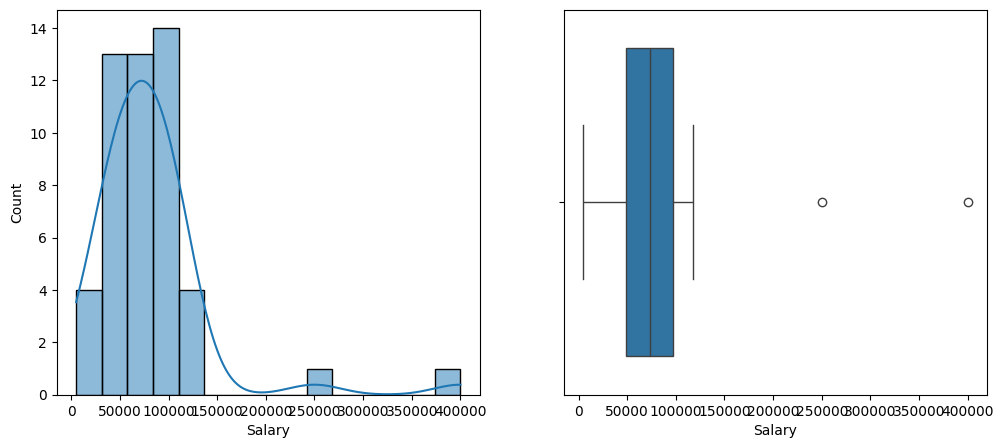

In [9]:
# to check outliers using subplots (histogram and boxplot)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Salary'], kde=True)

plt.subplot(1,2,2)
sns.boxplot(data = df, x = 'Salary')
plt.show()

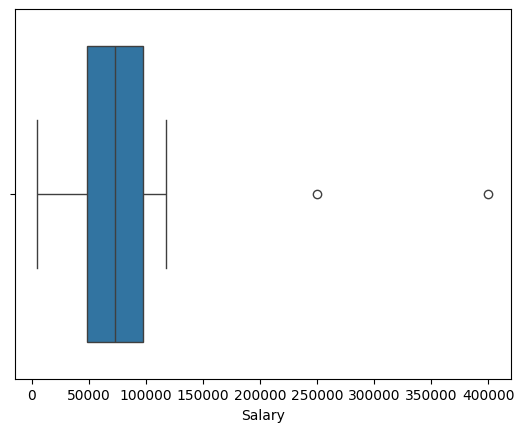

In [10]:
# boxplot 
sns.boxplot(data = df, x = 'Salary')
plt.show()

In [11]:
# lets drop the outliers 
df_no_outliers = df[(df['Salary'] >= lower_bound) & (df['Salary'] <= upper_bound)]
df_no_outliers.shape

(48, 1)

In [13]:
df.shape

(50, 1)

In [14]:
""" hence we have dropped 2 outliers from the dataset """

' hence we have dropped 2 outliers from the dataset '

In [ ]:
# where syntax
# np.where(condition, value_if_true, value_if_false)


# How it works:
# Checks condition element by element.
# If True, picks value_if_true.
# If False, picks value_if_false.

In [16]:
# mean imputation
df_salary_mean_imputed  = np.where((df.Salary > upper_bound) | (df.Salary < lower_bound), df.Salary.mean(), df.Salary)

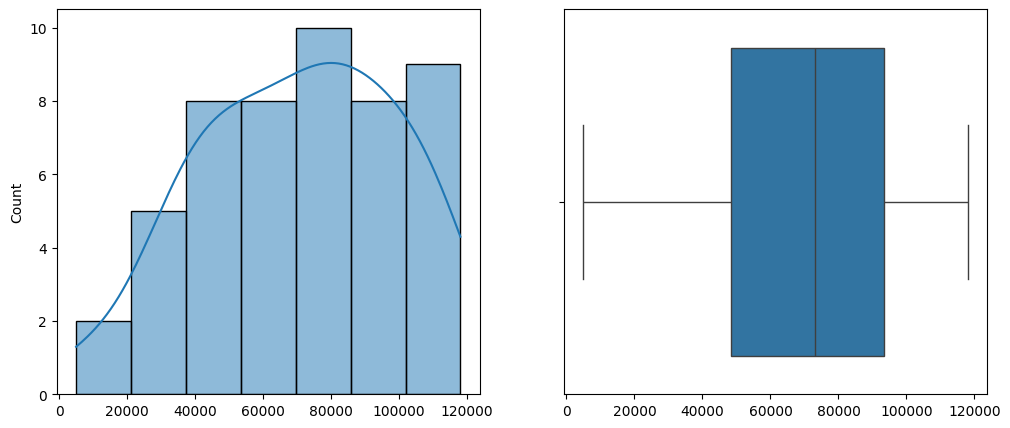

In [20]:
# visualize the imputed data
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_salary_mean_imputed, kde=True)
plt.subplot(1,2,2)
sns.boxplot(x=df_salary_mean_imputed)
plt.show()


In [22]:
# Capping of outlier 
# replace values above upper bound with upper bound and values below lower bound with lower bound

In [24]:
df_salary_cap = pd.DataFrame(np.where(df.Salary > upper_bound, upper_bound, np.where(df.Salary < lower_bound, lower_bound, df.Salary)))
df_salary_cap

,0
0,28000.0
1,30000.0
2,32000.0
3,34000.0
4,36000.0
5,38000.0
6,40000.0
7,42000.0
8,44000.0
9,46000.0


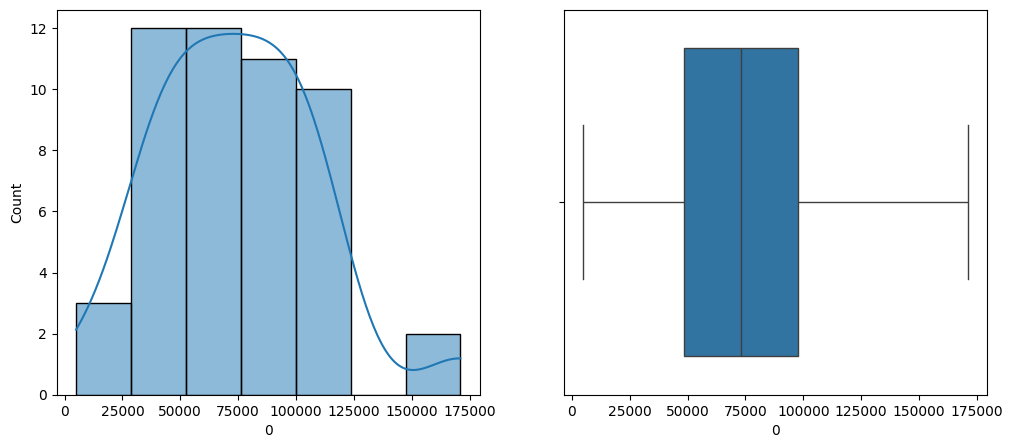

In [25]:
# visualize the capped data
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_salary_cap[0], kde=True)
plt.subplot(1,2,2)
sns.boxplot(x=df_salary_cap[0])
plt.show()